In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ast

# import data
parl_questions_labelled = pd.read_csv(
    "../01_data/empirical_analysis/speech_datasets/datasets_cluster_labels/parl_questions_clusterlabels.csv",
    parse_dates=["date", "birth_date"],
    dtype={
        "days_until_election": "int64",
        "agenda": "string",
        "text": "string",
        "sentence": "string",
        "speech_id": "int64",
        "speechnumber": "int64",
        "speaker": "string",
        "party": "category",
        "chair": "boolean",
        "age": "int64",
        "gender": "category",
        "vulnerability": "float64",
        "backbencher": "boolean",
        "constituency_name": "string",
        "ons_id": "string",
        "under_30": "float64",
        "over_65": "float64",
    },
    converters={
        "sg_spans": ast.literal_eval,
        "stances": ast.literal_eval,
        "sg_categories": ast.literal_eval
    }
)

pred_counts_youth_appeals = pd.read_csv("analysis_results/pred_counts_youth_appeals.csv")
pred_counts_elderly_appeals = pd.read_csv("analysis_results/pred_counts_elderly_appeals.csv")
pred_prob_lab_vote = pd.read_csv("analysis_results/pred_probs_youth_appeals.csv")
pred_prob_con_vote = pd.read_csv("analysis_results/pred_probs_elderly_appeals.csv")
ame_diffs_youth = pd.read_csv("analysis_results/ame_diffs_youth.csv")
ame_diffs_elderly = pd.read_csv("analysis_results/ame_diffs_elderly.csv")

# **Exploratory Data Analysis**

## Mean Appeals over Time

First, I investigate the average number of appeals over time. It is interesting to see, whether appeal usage increases the closer the next general election comes.

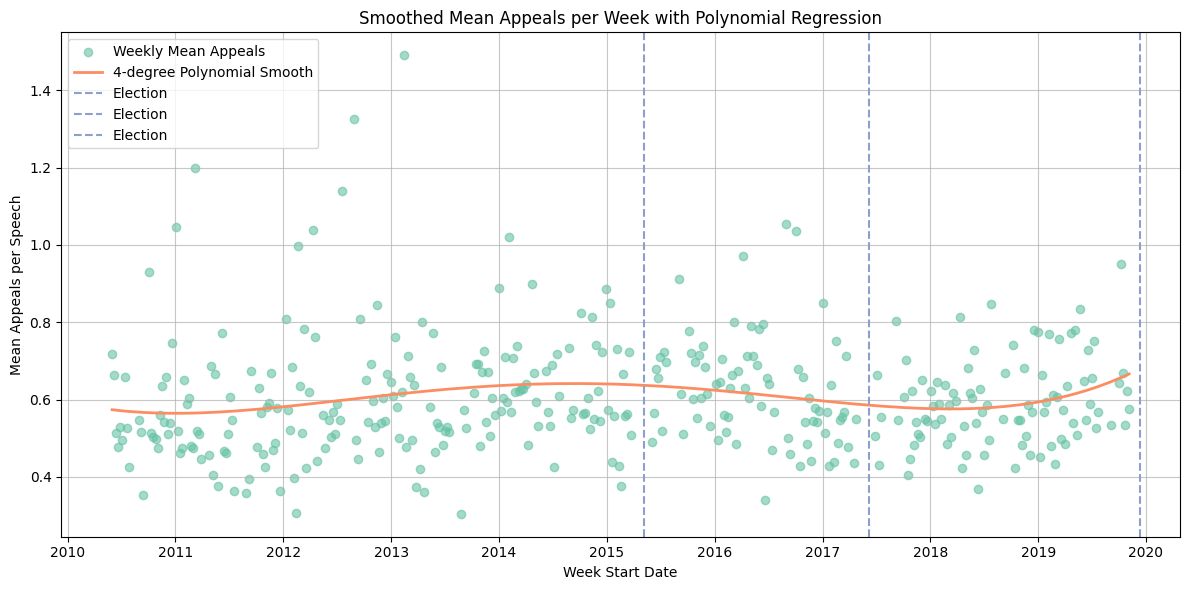

In [2]:
# count total appeals per sentence
parl_questions_labelled["total_appeals"] = parl_questions_labelled["stances"].apply(
    lambda stances: sum(1 for s in stances if s in ["positive", "negative"])
)

# aggregate per speech
appeals_per_speech = parl_questions_labelled.groupby("speech_id").agg(
    total_appeals=("total_appeals", "sum"),
    date=("date", "first")
).reset_index()

# calculate mean appeals per speech per week
weekly_mean_appeals = (
    appeals_per_speech
    .groupby(pd.Grouper(key="date", freq="W-MON"))["total_appeals"]
    .mean()
    .reset_index()
)

# get the first day of the week
weekly_mean_appeals["week_start"] = weekly_mean_appeals["date"] - pd.to_timedelta(6, unit="d")
weekly_mean_appeals = weekly_mean_appeals.drop(columns="date")

# drop weeks with no speeches
weekly_mean_appeals = weekly_mean_appeals.dropna()

# apply polynomial smoothing
degree = 4
x = weekly_mean_appeals["week_start"].map(pd.Timestamp.toordinal).values
y = weekly_mean_appeals["total_appeals"].values
coeffs = np.polyfit(x, y, degree)
poly = np.poly1d(coeffs)
y_smooth = poly(x)

# set election dates
election_dates = [pd.to_datetime("2015-05-07"), pd.to_datetime("2017-06-08"), pd.to_datetime("2019-12-12")]

# plot the development over time
plt.figure(figsize=(12, 6))
plt.scatter(weekly_mean_appeals["week_start"], y, color=plt.cm.Set2.colors[0], alpha=0.6, label='Weekly Mean Appeals')
plt.plot(weekly_mean_appeals["week_start"], y_smooth, color=plt.cm.Set2.colors[1], linewidth=2, label=f'{degree}-degree Polynomial Smooth')
for date in election_dates:
    plt.axvline(date, color=plt.cm.Set2.colors[2], linestyle='--', alpha=1, label='Election')
plt.xlabel("Week Start Date")
plt.ylabel("Mean Appeals per Speech")
plt.title("Smoothed Mean Appeals per Week with Polynomial Regression")
plt.legend()
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

## Proportion of Appeals and Stances Across Parties

In [3]:
counter = 0
for _, row in parl_questions_labelled.iterrows():
    appeals = row["stances"]
    for appeal in appeals:
        if (appeal == "positive") or (appeal == "negative"):
            counter += 1
            break

print(len(parl_questions_labelled))
print(counter)
print(counter/len(parl_questions_labelled))

515768
89672
0.17386111585053746


In [5]:
# subset to only Labour or Tory politicians
major_parties_df = parl_questions_labelled[parl_questions_labelled["party"].isin(["Lab", "Con", "LibDem", "SNP"])].copy()
major_parties_df["party"] = major_parties_df["party"].cat.set_categories(["Lab", "Con", "LibDem", "SNP"])

# count total appeals per sentence
major_parties_df["total_appeals"] = major_parties_df["stances"].apply(lambda stances: sum(1 for s in stances if s in ["positive", "negative"]))

# count stances per sentence
major_parties_df["positive_appeals"] = major_parties_df["stances"].apply(lambda stances: sum(1 for s in stances if s == "positive"))
major_parties_df["neutral_appeals"] = major_parties_df["stances"].apply(lambda stances: sum(1 for s in stances if s == "neutral"))
major_parties_df["negative_appeals"] = major_parties_df["stances"].apply(lambda stances: sum(1 for s in stances if s == "negative"))

# get mean number of appeals per party per sentence
mean_appeals_per_sentence = major_parties_df.groupby("party", observed=True)["total_appeals"].mean()

# aggregate to appeals per speech
appeals_per_speech = major_parties_df.groupby("speech_id").agg(
    party = ("party", "first"),
    total_appeals = ("total_appeals", "sum")
)

# get mean appeals per party per speech
mean_appeals_per_speech = appeals_per_speech.groupby("party", observed=True)["total_appeals"].mean()

# count stance types per party and normalize
stances_per_party = major_parties_df.groupby("party", observed=True)[["positive_appeals", "neutral_appeals", "negative_appeals"]].sum()
stance_shares_per_party = stances_per_party.div(stances_per_party.sum(axis=1), axis=0)

print("Average number of appeals per party per sentence:")
display(pd.DataFrame(mean_appeals_per_sentence))

print("Average number of appeals per party per speech:")
display(pd.DataFrame(mean_appeals_per_speech))

print("Proportion of stance types per party:")
display(stance_shares_per_party)

Average number of appeals per party per sentence:


,total_appeals
party,
Lab,0.269874
Con,0.202973
LibDem,0.197802
SNP,0.232289


Average number of appeals per party per speech:


,total_appeals
party,
Lab,0.695822
Con,0.567537
LibDem,0.534334
SNP,0.565070


Proportion of stance types per party:


,positive_appeals,neutral_appeals,negative_appeals
party,,,
Lab,0.608020,0.332883,0.059097
Con,0.619639,0.328757,0.051604
LibDem,0.619205,0.336938,0.043857
SNP,0.677190,0.294353,0.028457


## Most Targeted Groups

In [6]:
# extract all positive or negative appeals
sg_counts_df = parl_questions_labelled.copy()
sg_counts_df = sg_counts_df[(sg_counts_df["sg_categories"].str.len() > 0) & (sg_counts_df["stances"].str.len() > 0)]
sg_counts_df_exploded = sg_counts_df.explode(["sg_categories", "stances"])
sg_counts_df_exploded = sg_counts_df_exploded[sg_counts_df_exploded["stances"].isin(["positive", "negative"])]

# count frequency of social group categories
sg_counts_overall = sg_counts_df_exploded["sg_categories"].value_counts()

# count frequencies of categories and proportions within parties
sg_counts_df_exploded_lab_con = sg_counts_df_exploded[sg_counts_df_exploded["party"].isin(["Lab", "Con"])].copy()
sg_counts_df_exploded_lab_con["party"] = sg_counts_df_exploded_lab_con["party"].cat.set_categories(["Lab", "Con"])
sg_counts_lab_con = sg_counts_df_exploded_lab_con.groupby(["party", "sg_categories"], observed=True).size().reset_index(name="count")
sg_counts_lab_con["proportion"] = sg_counts_lab_con.groupby("party", observed=True)["count"].transform(lambda x: x / x.sum())
sg_props_lab_con = sg_counts_lab_con.pivot(index="sg_categories", columns="party", values="proportion")

# get the top 10 targeted groups
top_8_overall = sg_counts_overall.head(8).index

# reduce labour and conservative proportions to these categories
top_8_lab_con = sg_props_lab_con.loc[top_8_overall]

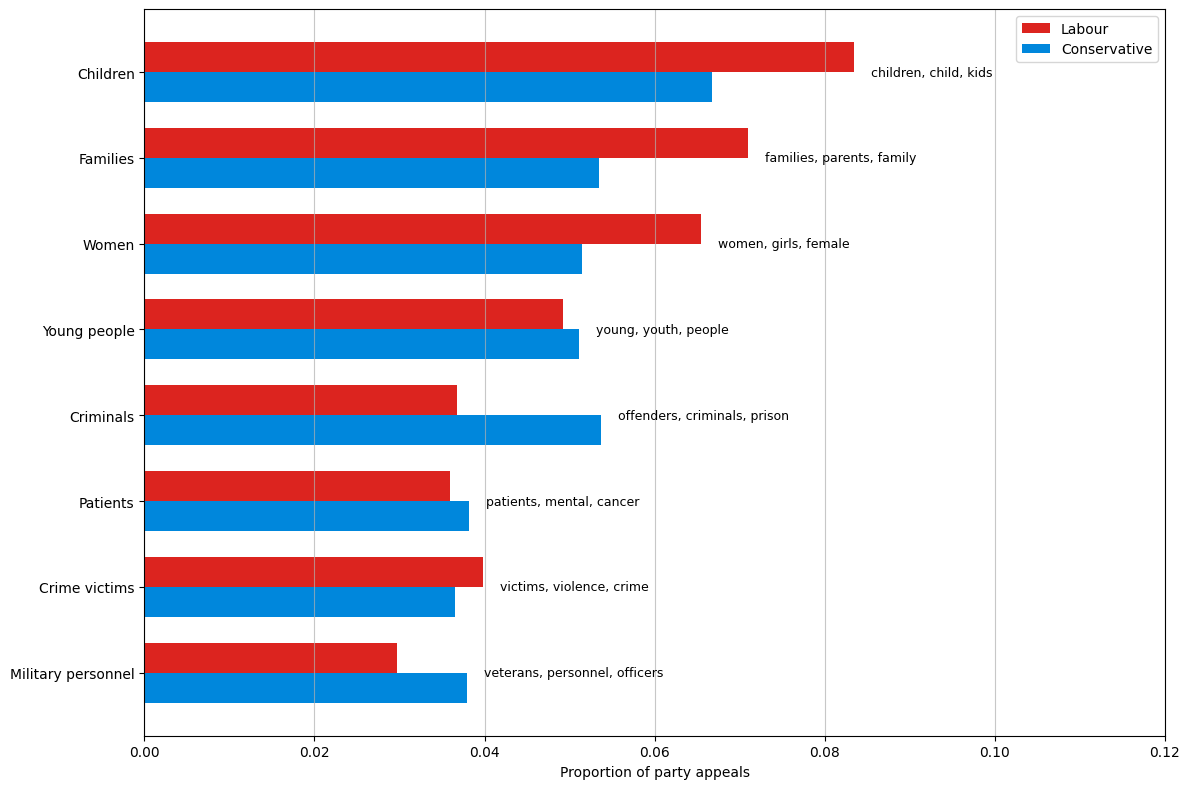

In [7]:
# plot the top 10 social group categories
y = np.arange(len(top_8_lab_con))
height = 0.35

fig, ax = plt.subplots(figsize=(12,8))

bars_lab = ax.barh(y - height/2, top_8_lab_con["Lab"], height, label="Labour", color="#DC241f")
bars_con = ax.barh(y + height/2, top_8_lab_con["Con"], height, label="Conservative", color="#0087DC")

pair_labels = ["children, child, kids", "families, parents, family", "women, girls, female", "young, youth, people",
               "offenders, criminals, prison", "patients, mental, cancer", "victims, violence, crime", "veterans, personnel, officers"]

for i, label in enumerate(pair_labels):
    y_center = y[i]
    x_pos = max(top_8_lab_con["Lab"].iloc[i], top_8_lab_con["Con"].iloc[i]) + 0.002
    ax.text(x_pos, y_center, label, va='center', ha='left', fontsize=9)

# Labels and title
ax.set_xlim(0, 0.12)
ax.set_yticks(y)
ax.set_yticklabels(top_8_lab_con.index)
ax.set_xlabel("Proportion of party appeals")
ax.invert_yaxis()
ax.xaxis.grid(True, alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

## Explanation Positive and Negative Appeals by Party Status

# **Empirical Analysis**
## Analysis of Usage Patterns of Age-Based Appeals

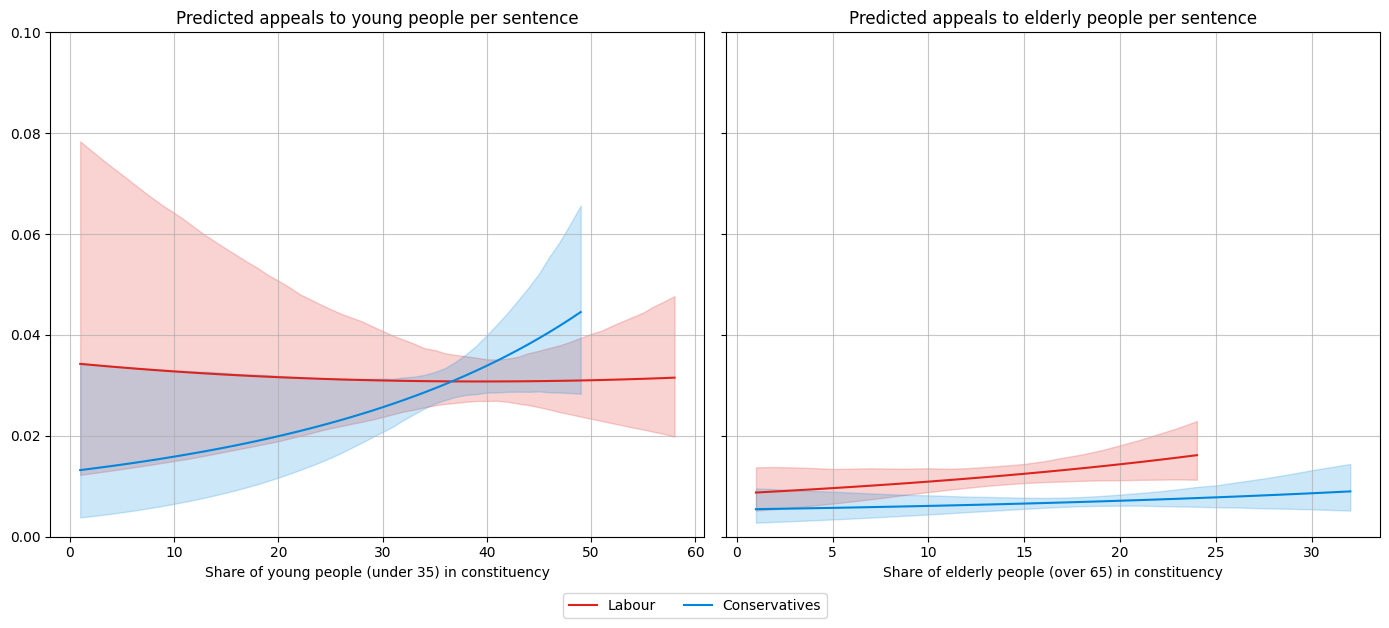

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

ax = axes[0]
for party, color in zip(["Lab", "Con"], ["#DC241f", "#0087DC"]):
    df = pred_counts_youth_appeals[pred_counts_youth_appeals["party"] == party]
    ax.plot(df["constituency_share"], df["pred"], color=color, label=party)
    ax.fill_between(df["constituency_share"], df["lower"], df["upper"], color=color, alpha=0.2)
ax.set_xlabel("Share of young people (under 35) in constituency")
ax.set_ylim(0, 0.1)
ax.set_title("Predicted appeals to young people per sentence")
ax.xaxis.grid(True, alpha=0.7)
ax.yaxis.grid(True, alpha=0.7)

ax = axes[1]
for party, color in zip(["Lab", "Con"], ["#DC241f", "#0087DC"]):
    df = pred_counts_elderly_appeals[pred_counts_elderly_appeals["party"] == party]
    ax.plot(df["constituency_share"], df["pred"], color=color, label=party)
    ax.fill_between(df["constituency_share"], df["lower"], df["upper"], color=color, alpha=0.2)
ax.set_xlabel("Share of elderly people (over 65) in constituency")
ax.set_title("Predicted appeals to elderly people per sentence")
ax.xaxis.grid(True, alpha=0.7)
ax.yaxis.grid(True, alpha=0.7)

handles, _ = axes[0].get_legend_handles_labels()
fig.legend(handles, ["Labour", "Conservatives"],
           loc="lower center",
           bbox_to_anchor=(0.5, -0.05),
           ncol=2)

plt.tight_layout()
plt.show()

## Analysis of the Effects on Voters

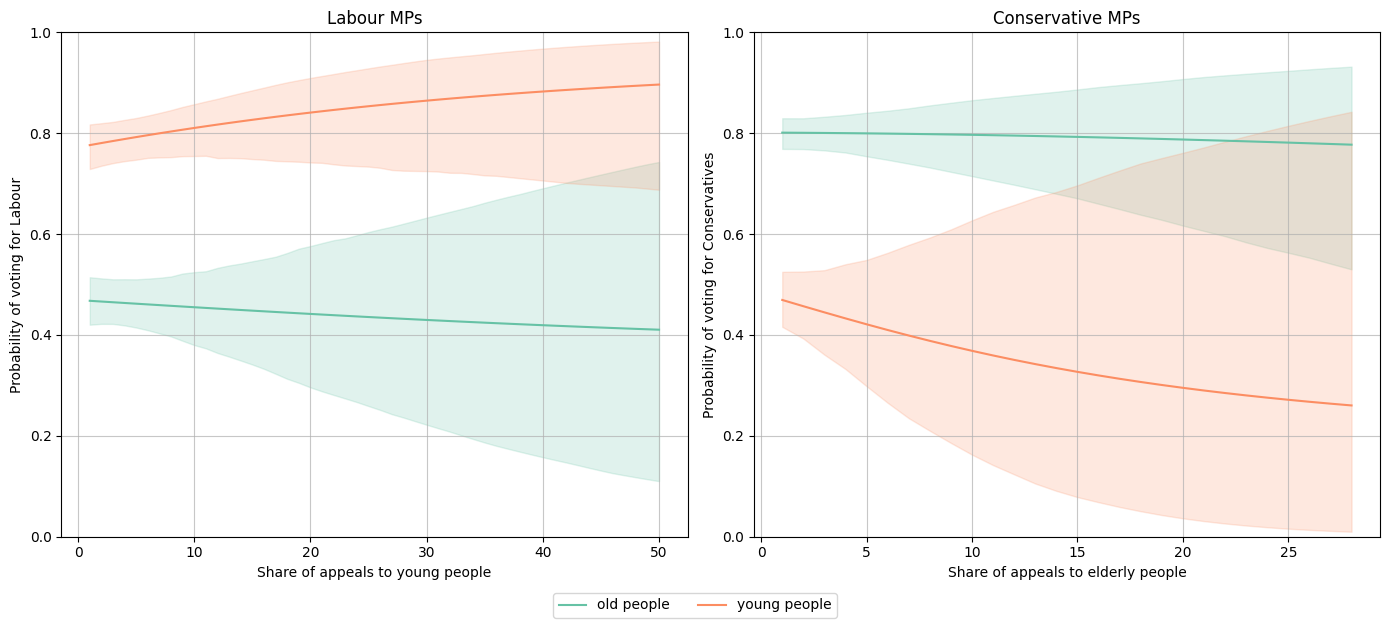

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=False)

ax = axes[0]
for age_group, color in zip(["old", "young"], [plt.cm.Set2.colors[0], plt.cm.Set2.colors[1]]):
    df = pred_prob_lab_vote[pred_prob_lab_vote["age_group"] == age_group]
    ax.plot(df["age_appeal_share"], df["pred"], color=color, label=age_group)
    ax.fill_between(df["age_appeal_share"], df["lower"], df["upper"], color=color, alpha=0.2)
ax.set_xlabel("Share of appeals to young people")
ax.set_ylabel("Probability of voting for Labour")
ax.set_ylim(0, 1)
ax.set_title("Labour MPs")
ax.xaxis.grid(True, alpha=0.7)
ax.yaxis.grid(True, alpha=0.7)

ax = axes[1]
for age_group, color in zip(["old", "young"], [plt.cm.Set2.colors[0], plt.cm.Set2.colors[1]]):
    df = pred_prob_con_vote[pred_prob_con_vote["age_group"] == age_group]
    ax.plot(df["age_appeal_share"], df["pred"], color=color, label=age_group)
    ax.fill_between(df["age_appeal_share"], df["lower"], df["upper"], color=color, alpha=0.2)
ax.set_xlabel("Share of appeals to elderly people")
ax.set_ylabel("Probability of voting for Conservatives")
ax.set_ylim(0, 1)
ax.set_title("Conservative MPs")
ax.xaxis.grid(True, alpha=0.7)
ax.yaxis.grid(True, alpha=0.7)

handles, _ = axes[0].get_legend_handles_labels()
fig.legend(handles, ["old people", "young people"],
           loc="lower center",
           bbox_to_anchor=(0.5, -0.05),
           ncol=2)

plt.tight_layout()
plt.show()

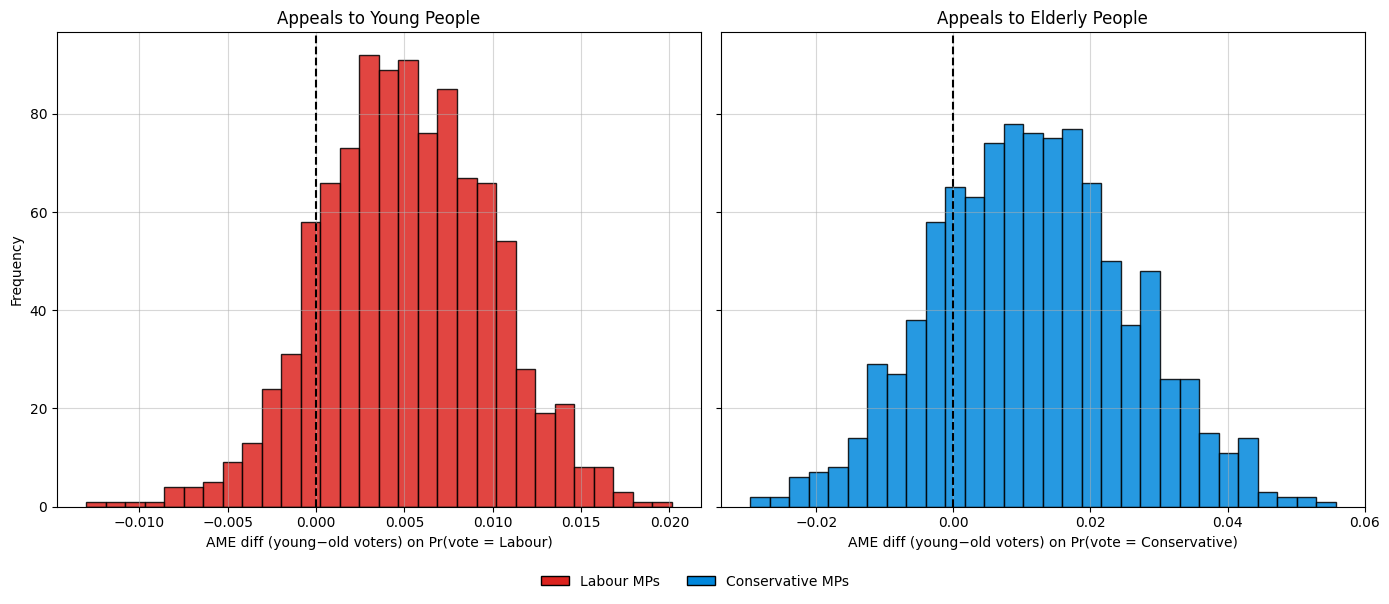

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

datasets = [
    (ame_diffs_youth, "Appeals to Young People"),
    (ame_diffs_elderly, "Appeals to Elderly People")
]

parties = ["Labour", "Conservative"]

party_colors = {
    "Labour": "#DC241f",
    "Conservative": "#0087DC"
}

for col, (data, col_title) in enumerate(datasets):

    ax = axes[col]

    bins = np.histogram_bin_edges(data["ame_diff"], bins=30)

    for party in parties:

        df = data[data["party"] == party]

        ax.hist(
            df["ame_diff"],
            bins=bins,
            color=party_colors[party],
            alpha=0.85,
            edgecolor="black"
        )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.5
    )

    ax.xaxis.grid(True, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.5)
    ax.set_title(col_title)

axes[0].set_ylabel("Frequency")

axes[0].set_xlabel("AME diff (young−old voters) on Pr(vote = Labour)")
axes[1].set_xlabel("AME diff (young−old voters) on Pr(vote = Conservative)")

# legend
legend_elements = [
    Patch(facecolor=party_colors["Labour"], edgecolor="black", label="Labour MPs"),
    Patch(facecolor=party_colors["Conservative"], edgecolor="black", label="Conservative MPs")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()